In [1]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle
import joblib
from scipy.stats import pearsonr


import cartopy.crs as ccrs
import matplotlib as mpl

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['font.sans-serif']=['Verdana']

params = {"ytick.color": "k",
          "xtick.color": "k",
          "axes.labelcolor": "k",
          "axes.edgecolor": "k"}
plt.rcParams.update(params)

# import imageio

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve


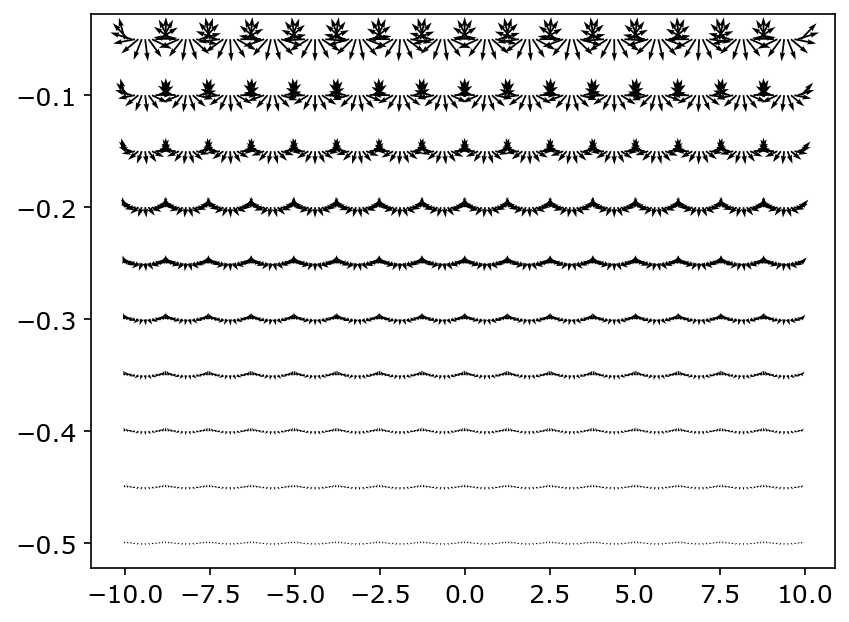

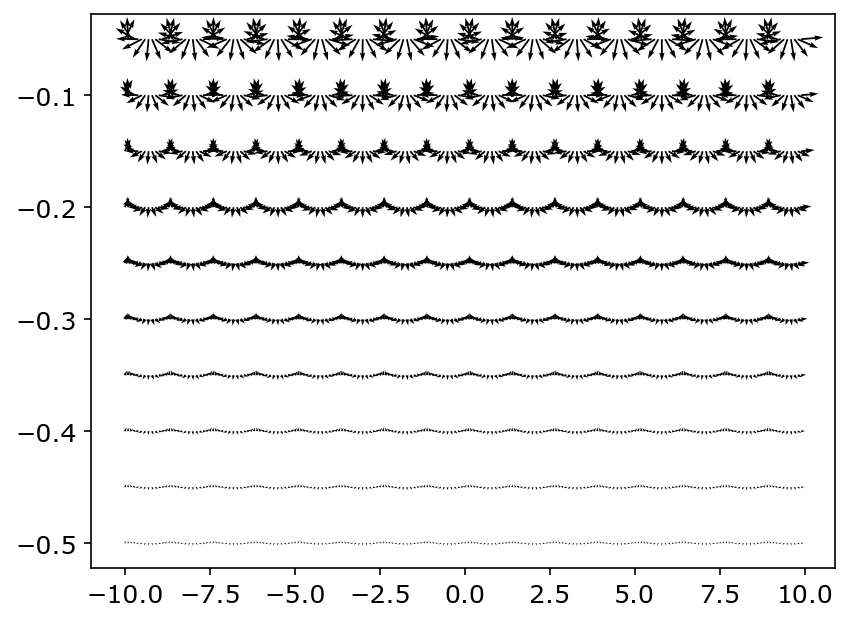

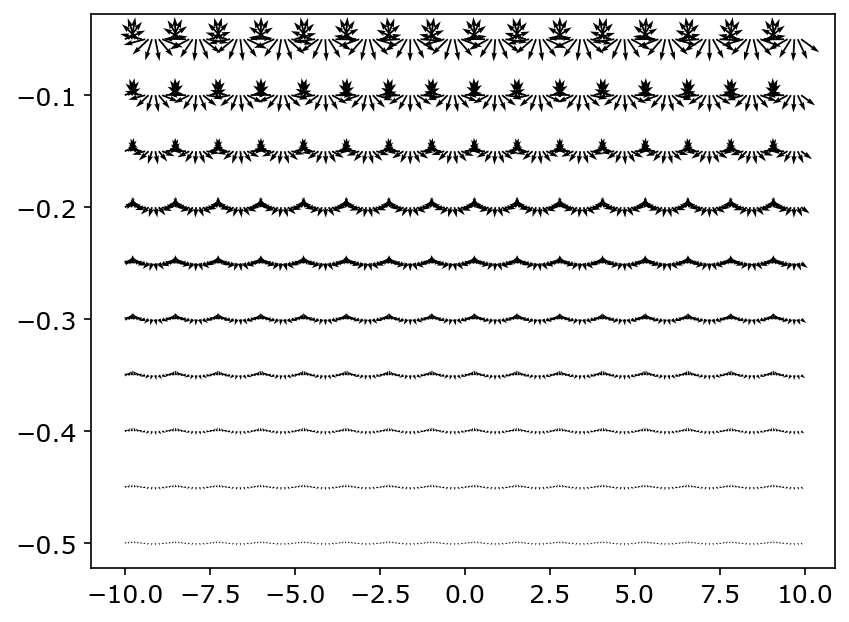

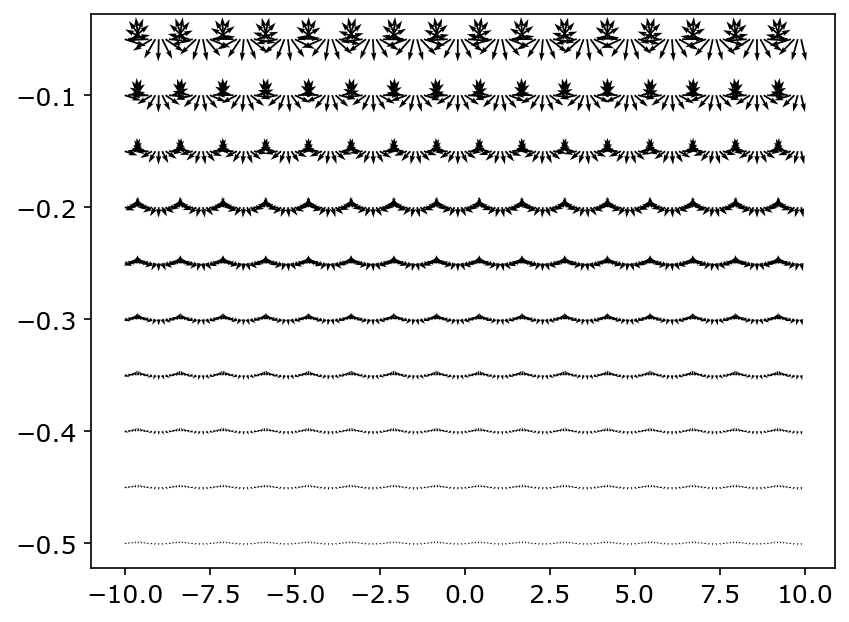

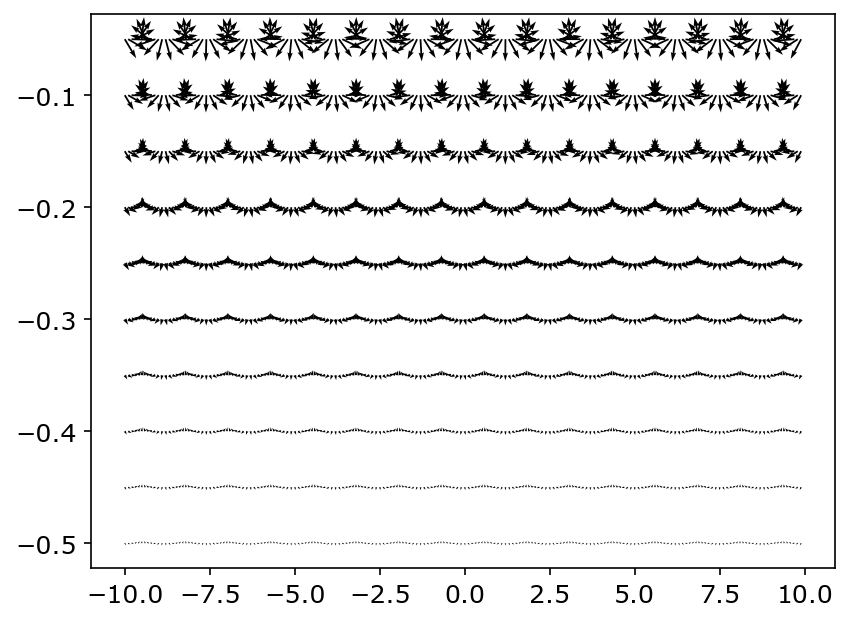

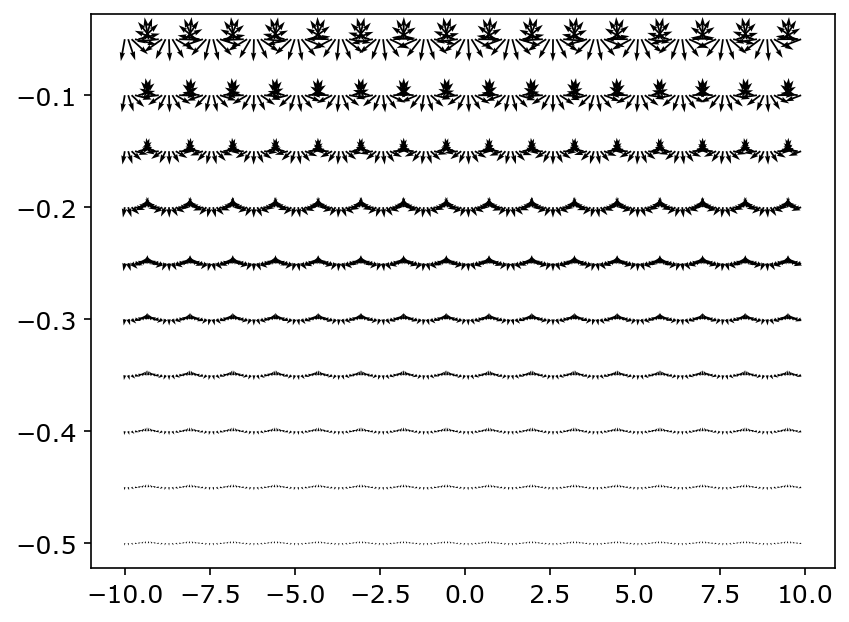

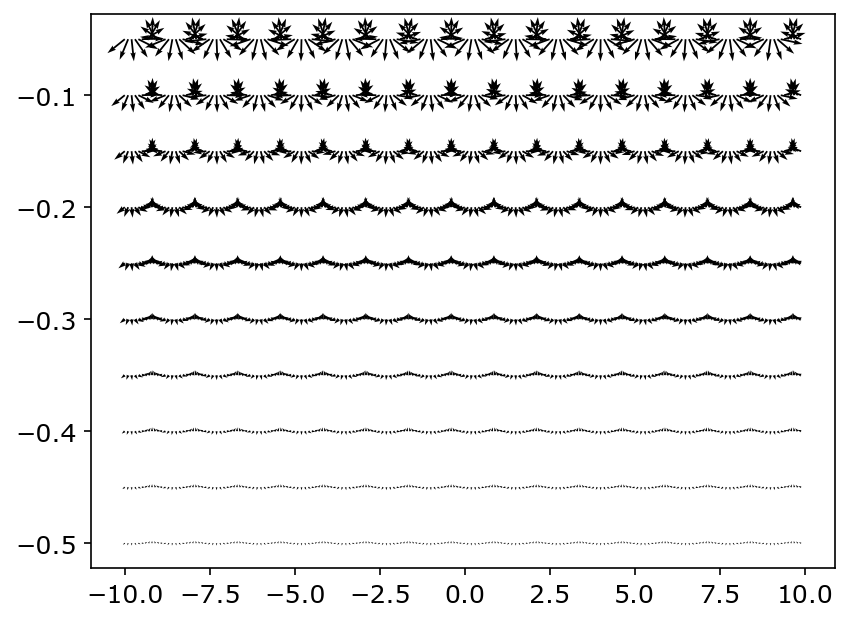

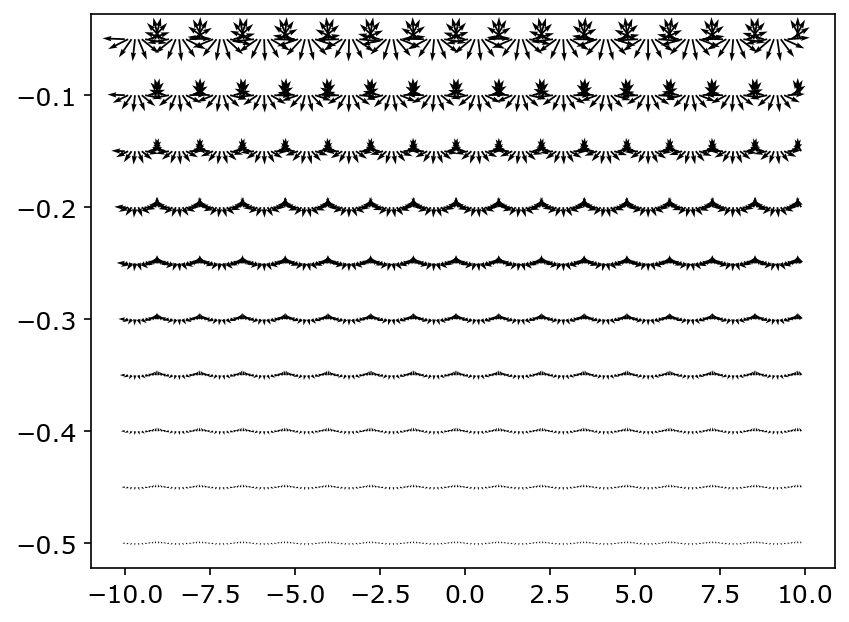

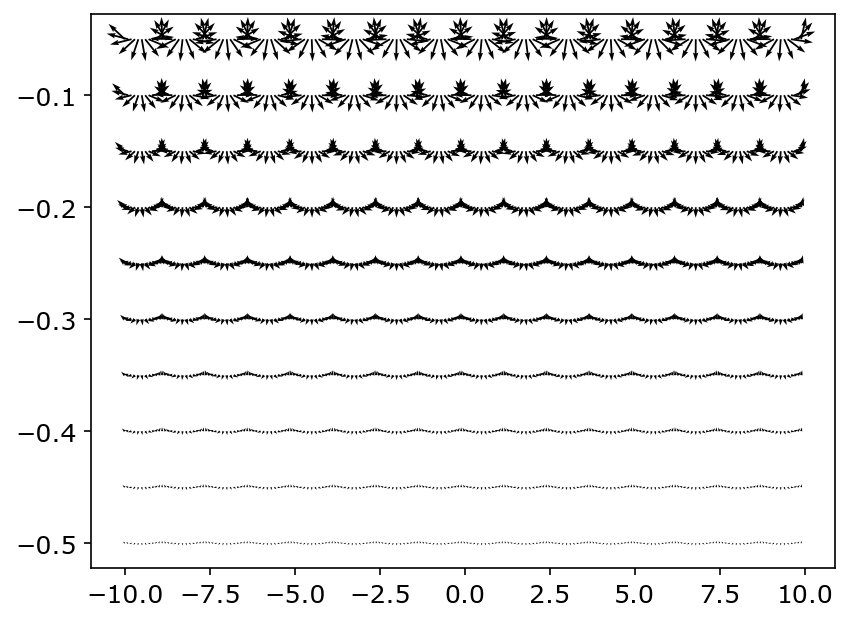

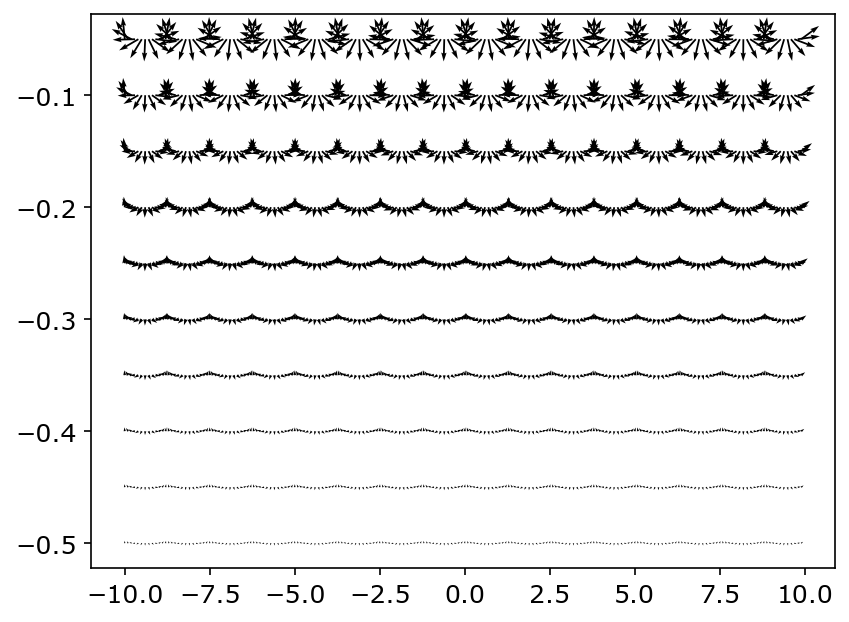

In [12]:
z = np.arange(-0.5,0,0.05)
k = 5
A = 0.0001
xvec = np.arange(-10,10,0.1)

meshx,meshz = np.meshgrid(xvec,z)

for t in range(0,10,1):
    vx = np.real(1j*k*A*np.exp(1j*(k*meshx-np.sqrt(9.8*k)*t))*np.exp(k*meshz))
    vz = np.real(k*A*np.exp(1j*(k*meshx-np.sqrt(9.8*k)*t))*np.exp(k*meshz))

    plt.quiver(xvec,z,vx,vz)
    plt.show()

In [239]:
ssplist = ["126","245","370","585"]

# set user parameters

# experiment_era = [1950,2100]
experiment_era = [1980,2100]

# baselineera = [1900,1950]
baselineera = [1950,1980]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1980,2025]
# baselineera_obs = [1940,1960]
baselineera_obs = [1950,1980]

inputlength = 10
# outputavgtime = 3

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
# modelfilefront = "MPI_histrecord_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

obstimerange = [1940,2025]

data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]



In [240]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "data_dir":data_dir,
}

ntrain = 25
nval = 13
test = np.arange(38,50)


#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [241]:
latsel = 40
lonsel = 30
outputavgtime = 5

ilonsel = int(lonsel/10)

In [242]:
trainvaltest = [np.arange(25),np.arange(25,38),test]

alltrain, allval, alltest = AllData.trainvaltest_histrecordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)
# alltrain, allval, alltest = AllData.trainvaltest_recordmax_withrecordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

inputtrain, inputtrainvecs,outputtrainall = DataHolder.tensortime_onehot_withrecordmax(alltrain,nclasses=2)
inputtest, inputtestvecs, outputtest = DataHolder.tensortime_onehot_withrecordmax(alltest,nclasses=2)

inputtestGMT = inputtestvecs[:,0]

outputtrain = np.argmax(outputtrainall.numpy(),axis=1)
outputtest = np.argmax(outputtest.numpy(),axis=1)

inputssptrain,inputsspval,inputssptest = AllData.trainvaltest_recordmax_ssps(trainvaltest,experiment_era,inputlength,outputavgtime,latsel)

inputssptrain = np.round((inputssptrain.squeeze()+0.2)*10)
inputssptest = np.round((inputssptest.squeeze()+0.2)*10)


baseline for temp records is 50 80 (not used)
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/predictability_emergence/DataHolder.py:2038: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


In [243]:
testfileout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_testing.json"
fileload = glob.glob(testfileout)

with open(testfileout, "r") as f:
    data = json.load(f)
    bestaccs = np.array(data["test_accuracy"])
    nulls = np.max(np.array(data["test_class_imbalance"]))

filepredictions = "predictions/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_testing.pkl"

with open(filepredictions,'rb') as f:
    predictions = pickle.load(f)

filetrue = "predictions/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_truetesting.pkl"

with open(filetrue,'rb') as f:
    truths = pickle.load(f)

avgtestpred = np.mean(predictions,axis=1)
avgtestclass = np.round(avgtestpred)
avgtestconf = np.where(avgtestpred<0.5,1-avgtestpred,avgtestpred)

bs_cnn = np.mean((avgtestpred[ilonsel]-truths[ilonsel])**2)

In [244]:
obsparams = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

AllObs = DataHolder.ERA5InputOutput(obsparams)

In [245]:
device = 'mps'
# device = 'cpu'
n_best = 3

metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed*.json"
filelist = glob.glob(metricsout)

if len(filelist)!=0:
    print('models exist, proceeding')

    bestseeds = helpers.get_best_files(filelist,n_best)
    obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_histrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)

    obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
    obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
    obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)

    obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)

    obspredall = np.empty((3,len(obsinputgmt)))

    for iseed,seed in enumerate(bestseeds):
        # load the model

        loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed_"+str(seed)+".pt"
        cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
        cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
        cnn.to(device)

        with torch.no_grad():
            cnn.eval()
            obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()

        obspredall[iseed] = obspred[:,1]
else:
    print('no model')


models exist, proceeding


In [246]:
lrmodelload = "lr_models/"+modelfilefront + "LogisticRegression_avgtime_"+str(outputavgtime)+"_lat_"+str(latsel)+"_lon_"+str(lonsel)+".joblib"
lrmodel = joblib.load(lrmodelload)

lrpred = lrmodel.predict_proba(inputtestGMT[:,np.newaxis])[:,1]

lrpredobs = lrmodel.predict_proba(obsinputgmt)[:,1]

Text(0, 0.5, 'predicted likelihood')

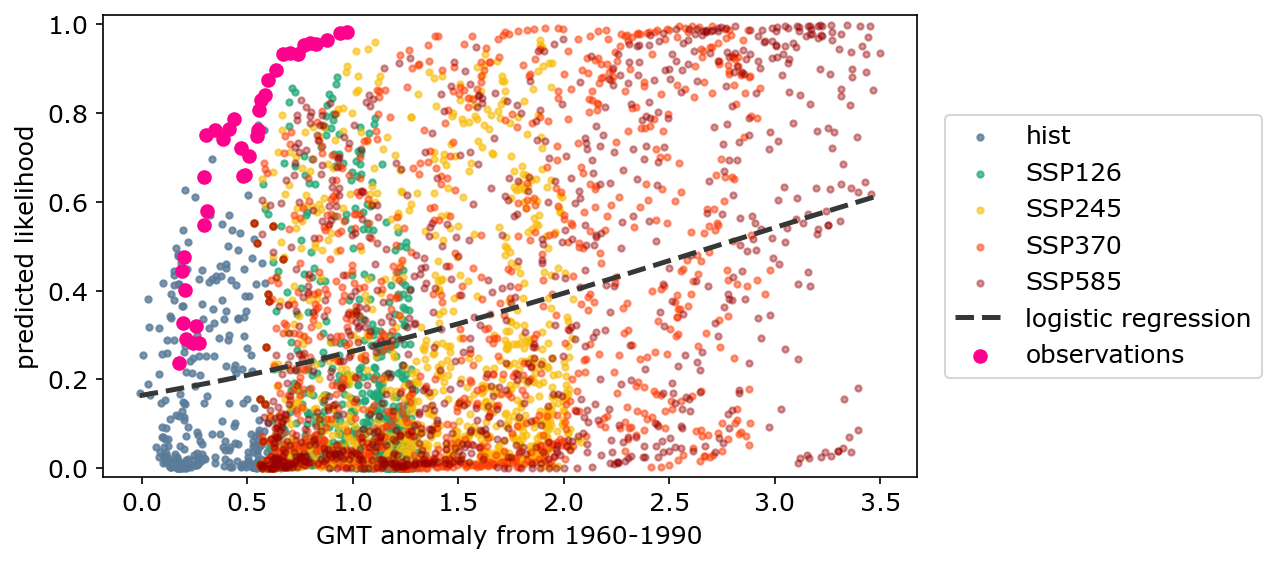

In [247]:
colors=['xkcd:slate blue','xkcd:jade','xkcd:golden rod','xkcd:red orange','xkcd:blood red']

ssplist = ['hist','SSP126','SSP245','SSP370','SSP585']

plt.figure(figsize=(7,4))

for i in range(5):

    plt.scatter(inputtestGMT.squeeze()[inputssptest==i],avgtestpred[ilonsel].squeeze()[inputssptest==i],marker='.',color=colors[i],alpha=(-0.1*i+0.8),label=ssplist[i])


sortindices = np.argsort(inputtestGMT.squeeze())

plt.plot(inputtestGMT.squeeze()[sortindices],lrpred[sortindices],color='xkcd:dark gray',linewidth=2.4,linestyle='dashed',label='logistic regression',zorder=5)

plt.scatter(obsinputgmt.squeeze(),np.mean(obspredall,axis=0),color='xkcd:hot pink',label='observations',zorder=6)

plt.ylim(-0.02,1.02)
# plt.legend()

plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left')
# plt.legend(loc='outside right center')
plt.xlabel('GMT anomaly from 1960-1990')
plt.ylabel('predicted likelihood')


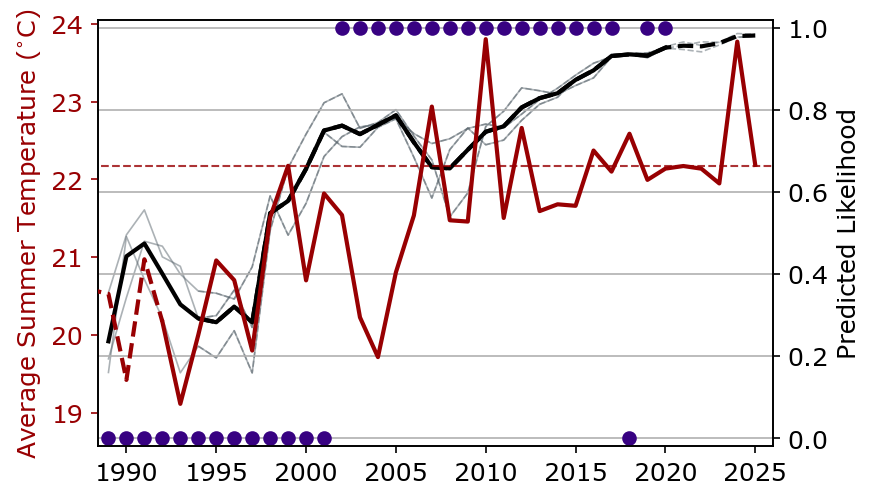

In [248]:
fig, ax2 = plt.subplots(figsize=(6,3.5))

xvec1 = np.arange(1989,2026)
xvec2 = np.arange(1992,2026)
xvec2a = np.arange(1980,1993)

bumpfactor = AllObs.regionalmean-273.15

# Create a twin axis that shares the same x-axis
ax1 = ax2.twinx()
ax2.set_zorder(ax1.get_zorder() + 1)
ax2.patch.set_visible(False) 

plt.grid(axis='y',zorder=-100)

ax2.plot(xvec2a, (AllObs.outputsummer-273.15)[:13],color='xkcd:blood red',linewidth=2,linestyle='dashed',zorder=5)
ax2.plot(xvec2, (AllObs.outputsummer-273.15)[12:],color='xkcd:blood red',linewidth=2,zorder=5,label='summer temperature')
# ax2.plot(xvec1,obsinputpriorrecord_t+bumpfactor,linewidth=1,alpha=0.8,color='xkcd:blood red')
ax2.hlines(obsinputpriorrecord_t[0]+bumpfactor,1988,2026,linewidth=1,alpha=0.8,color='xkcd:blood red',linestyle='dashed',zorder=5,label='historic max')
ax2.set_ylabel('Average Summer Temperature ($^{\circ}$C)',color='xkcd:blood red',zorder=5)
ax2.tick_params(axis='y', colors='xkcd:blood red')

# Plot first dataset on the primary y-axis (left)
ax1.plot(xvec1[:-outputavgtime],obspredall.T[:-outputavgtime],color='xkcd:slate grey',linewidth=0.8,alpha=0.5,zorder=1)
ax1.plot(xvec1[:-outputavgtime],np.mean(obspredall,axis=0)[:-outputavgtime],color='black',linewidth=2, label='average CNN',zorder=2)
ax1.plot(xvec1[outputavgtime:],obspredall.T[outputavgtime:],color='xkcd:slate grey',linewidth=0.8,alpha=0.5,zorder=1,linestyle='dashed')
ax1.plot(xvec1[outputavgtime:],np.mean(obspredall,axis=0)[outputavgtime:],color='black',linewidth=2, zorder=2,linestyle='dashed')
ax1.scatter(xvec1[:-1*outputavgtime],obsoutput,color="xkcd:indigo",label='event class',zorder=3)
ax1.set_xlabel('Year')
ax1.set_ylabel('Predicted Likelihood')
ax1.set_ylim(-0.02,1.02)

ax1.set_xlim(1988.4,2026)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right',bbox_to_anchor=(1.0, 0.05))

plt.tight_layout()

plt.savefig("figs/timeseries_"+str(latsel)+"_"+str(lonsel)+"histmax.png",dpi=300)
# plt.show()


In [249]:
device = 'mps'
# device = 'cpu'
n_best = 3

metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed*.json"
filelist = glob.glob(metricsout)

if len(filelist)!=0:
    print('models exist, proceeding')

    bestseeds = helpers.get_best_files(filelist,n_best)
    obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)

    obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
    obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
    obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)

    obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)

    obspredall = np.empty((3,len(obsinputgmt)))

    for iseed,seed in enumerate(bestseeds):
        # load the model

        loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed_"+str(seed)+".pt"
        cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
        cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
        cnn.to(device)

        with torch.no_grad():
            cnn.eval()
            obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()

        obspredall[iseed] = obspred[:,1]
else:
    print('no model')


models exist, proceeding


In [250]:
lrmodelload = "lr_models/"+modelfilefront + "LogisticRegression_avgtime_"+str(outputavgtime)+"_lat_"+str(latsel)+"_lon_"+str(lonsel)+".joblib"
lrmodel = joblib.load(lrmodelload)

lrpred = lrmodel.predict_proba(inputtestGMT[:,np.newaxis])[:,1]

lrpredobs = lrmodel.predict_proba(obsinputgmt)[:,1]

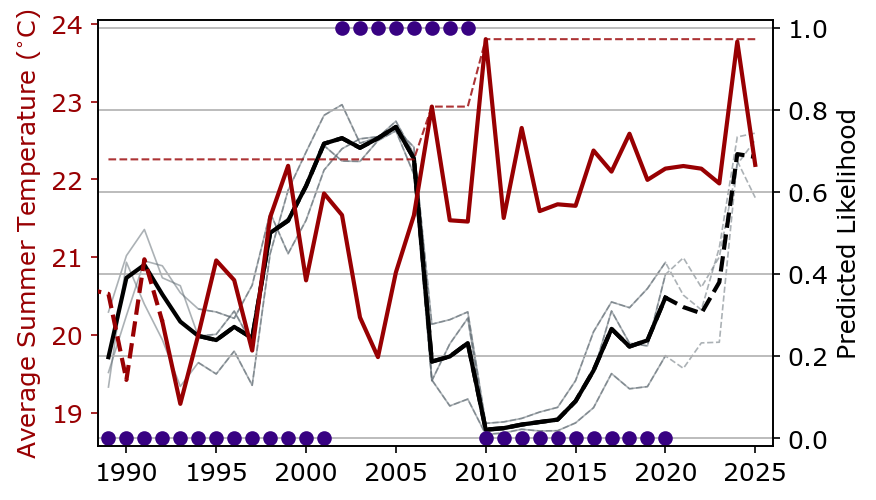

In [251]:
fig, ax2 = plt.subplots(figsize=(6,3.5))

xvec1 = np.arange(1989,2026)
xvec2 = np.arange(1992,2026)
xvec2a = np.arange(1980,1993)

bumpfactor = AllObs.regionalmean-273.15

# Create a twin axis that shares the same x-axis
ax1 = ax2.twinx()
ax2.set_zorder(ax1.get_zorder() + 1)
ax2.patch.set_visible(False) 

plt.grid(axis='y',zorder=-100)

ax2.plot(xvec2a, (AllObs.outputsummer-273.15)[:13],color='xkcd:blood red',linewidth=2,linestyle='dashed',zorder=5)
ax2.plot(xvec2, (AllObs.outputsummer-273.15)[12:],color='xkcd:blood red',linewidth=2,zorder=5,label='summer temperature')
ax2.plot(xvec1,obsinputpriorrecord_t+bumpfactor,linewidth=1,alpha=0.8,color='xkcd:blood red',linestyle='dashed',zorder=5,label='max threshold')
ax2.set_ylabel('Average Summer Temperature ($^{\circ}$C)',color='xkcd:blood red',zorder=5)
ax2.tick_params(axis='y', colors='xkcd:blood red')

# Plot first dataset on the primary y-axis (left)
ax1.plot(xvec1[:-outputavgtime],obspredall.T[:-outputavgtime],color='xkcd:slate grey',linewidth=0.8,alpha=0.5,zorder=1)
ax1.plot(xvec1[:-outputavgtime],np.mean(obspredall,axis=0)[:-outputavgtime],color='black',linewidth=2, label='average CNN',zorder=2)
ax1.plot(xvec1[outputavgtime:],obspredall.T[outputavgtime:],color='xkcd:slate grey',linewidth=0.8,alpha=0.5,zorder=1,linestyle='dashed')
ax1.plot(xvec1[outputavgtime:],np.mean(obspredall,axis=0)[outputavgtime:],color='black',linewidth=2, zorder=2,linestyle='dashed')
ax1.scatter(xvec1[:-outputavgtime],obsoutput,color="xkcd:indigo",label='event class',zorder=3)
ax1.set_xlabel('Year')
ax1.set_ylabel('Predicted Likelihood')
ax1.set_ylim(-0.02,1.02)

ax1.set_xlim(1988.4,2026)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', bbox_to_anchor=(1.1, 0.5))


plt.tight_layout()
plt.savefig("figs/timeseries_"+str(latsel)+"_"+str(lonsel)+"recordmax.png",bbox_inches='tight', dpi=300)
# plt.show()
